In [2]:
library(tidyverse)
library(readr)      
library(dplyr)
library(stringr)
library(janitor)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [3]:
data <- read_csv("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/data/ctg-studies.csv") %>%
  janitor::clean_names() %>%
  mutate(
    conditions = str_to_lower(conditions),
    phases     = str_to_upper(phases),
    sex        = str_to_title(sex),
    study_type = str_to_title(study_type),
    sex = factor(sex, 
                 levels = c("All","Male","Female"),
                 labels = c("All","Male","Female"))
  )  %>% 
  filter(str_detect(conditions, "covid|sars")) %>%
  dplyr::filter(study_type == "Interventional") 
 

Rows: 10161 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (18): NCT Number, Study Title, Study URL, Study Status, Brief Summary, ...
date  (1): Results First Posted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Phase distributation analysis base on number of Trials ###

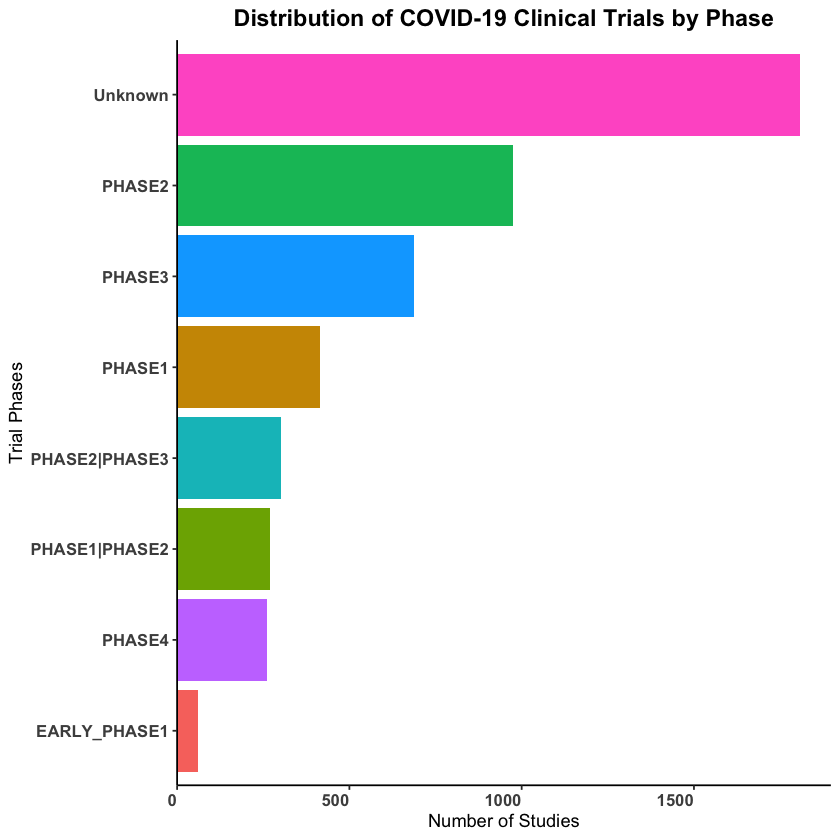

In [4]:
data %>% 
  mutate(
    phases = str_to_upper(phases),
    phases = tidyr::replace_na(phases, "Unknown")
  ) %>%
  group_by(phases) %>%
  summarise(n_studies = n(), .groups = "drop") %>%
  arrange(desc(n_studies)) %>% 
  
  ggplot(aes(x = n_studies,
             y = reorder(phases, n_studies),
             fill = phases)) +
  geom_col() +
  scale_x_continuous(expand = expansion(mult = c(0, 0.05))) +
  labs(x = "Phases", y = "Number of Studies", title = "Distribution of COVID-19 Clinical Trials by Phase") +
    labs(y = "Trial Phases", 
    x = "Number of Studies", 
    title = "Distribution of COVID-19 Clinical Trials by Phase") +
    theme_classic() +
    theme(
      legend.position = "none",
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 10),
          axis.text.y = element_text(size = 10, face = "bold"),
          plot.title = element_text(size = 14, face = "bold", hjust = 0.5)) 
     
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/phase_distribution.png", width = 8, height = 6)

#### Number of countris involved in clinical trials ####

In [10]:
library(dplyr)
library(stringr)
library(tidyr)

country_data <- data %>%
  filter(!is.na(locations)) %>%
  separate_rows(locations, sep = ";") %>%   # split multiple locations
  mutate(
    locations = str_trim(locations),
    country = str_extract(locations, "[^,]+$"),  # 🔥 take last part
    country = str_trim(country)
  )
head(country_data,1)

nct_number,study_title,study_url,study_status,brief_summary,study_results,conditions,interventions,sponsor,collaborators,sex,age,phases,study_type,start_date,primary_completion_date,completion_date,results_first_posted,locations,country
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>,<chr>
NCT05886790,A Clinical Trial on Booster Immunization of Two COVID-19 Vaccines Constructed From Different Technical Routes,https://clinicaltrials.gov/study/NCT05886790,UNKNOWN,"This is an open-label, randomized, parallel-controlled clinical trial conducted in people aged 18 years and older to evaluate the immunogenicity and safety of two SARS-CoV-2 bivalent vaccines constructed by adenovirus type 5-based or mRNA-based technics.",NO,covid-19,BIOLOGICAL: Prototype and Omicron BA.4/5 Bivalent Recombinant COVID-19 Vaccine(Adenovirus Type 5 Vector) For Inhalation|BIOLOGICAL: Bivalent COVID-19 mRNA Vaccine|BIOLOGICAL: Recombinant COVID-19 Vaccine (Adenovirus Type 5 Vector) For Inhalation,Zhongnan Hospital,"Institute of Biotechnology, Academy of Military Medical Sciences, PLA of China",All,"ADULT, OLDER_ADULT",NA,Interventional,2023-05-30,2023-12-31,2024-05-29,NA,"Zhongnan Hospital of Wuhan University, Wuhan, Hubei, 430000, China",China


In [6]:
country_summary <- country_data %>%
  mutate(
    country = case_when(
      country %in% c("United States", "USA") ~ "USA",
      country %in% c("United Kingdom") ~ "UK",
      TRUE ~ country
    )
  )%>%
  mutate(country = recode(country, `Turkey (Türkiye)` = "Turkey")) %>%
  count(country, sort = TRUE)
country_summary

country,n
<chr>,<int>
USA,1184
China,318
France,234
Spain,209
UK,171
Brazil,169
Canada,157
Turkey,148
Egypt,124


In [9]:
country_summary1 <- data %>%
  filter(!is.na(locations)) %>%
  separate_rows(locations, sep = ";") %>%
  mutate(
    locations = str_trim(locations),
    country = str_extract(locations, "[^,]+$"),
    country = str_trim(country)
  ) %>%
  mutate(
    country = case_when(
      str_detect(country, regex("india|delhi|mumbai|bangalore|chennai|hyderabad", ignore_case = TRUE)) ~ "India",
      str_detect(country, regex("pakistan|karachi|lahore", ignore_case = TRUE)) ~ "Pakistan",
      str_detect(country, regex("united states|usa", ignore_case = TRUE)) ~ "USA",
      str_detect(country, regex("united kingdom", ignore_case = TRUE)) ~ "UK",
      TRUE ~ country
    )
  ) %>%
  distinct(nct_number, country) %>%
  count(country, sort = TRUE)
  country_summary1

country,n
<chr>,<int>
USA,1190
China,318
France,234
Spain,209
UK,171
Brazil,169
Canada,157
Turkey (Türkiye),148
Egypt,124


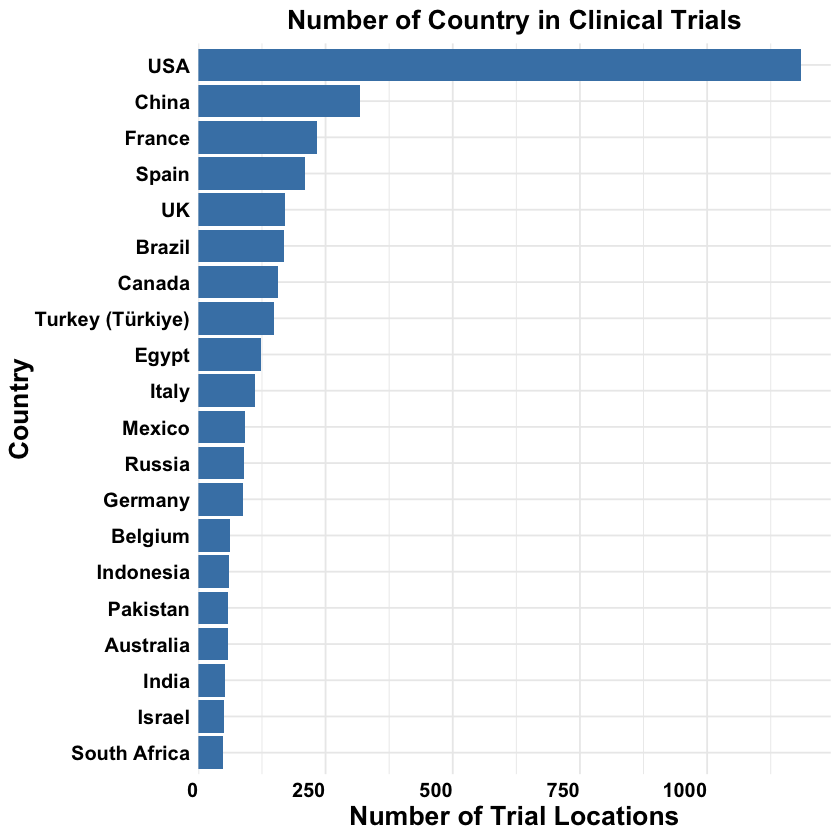

In [80]:
ggplot(country_summary[1:20,],
       aes(x = reorder(country, n), y = n)) +
  geom_col(fill = "steelblue") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  coord_flip() +
  labs(x = "Country", 
  y = "Number of Trial Locations",
     title = "Number of Country in Clinical Trials") +
    theme_minimal() +
    theme(
      legend.position = "none",
      axis.title = element_text(size = 16, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 12, colour = "black"),
      axis.text.y = element_text(size = 12, face = "bold",colour = "black"),
      plot.title = element_text(size = 16, face = "bold", hjust = 0.5,colour = "black"))
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/country_distribution.png", width = 8, height = 6)


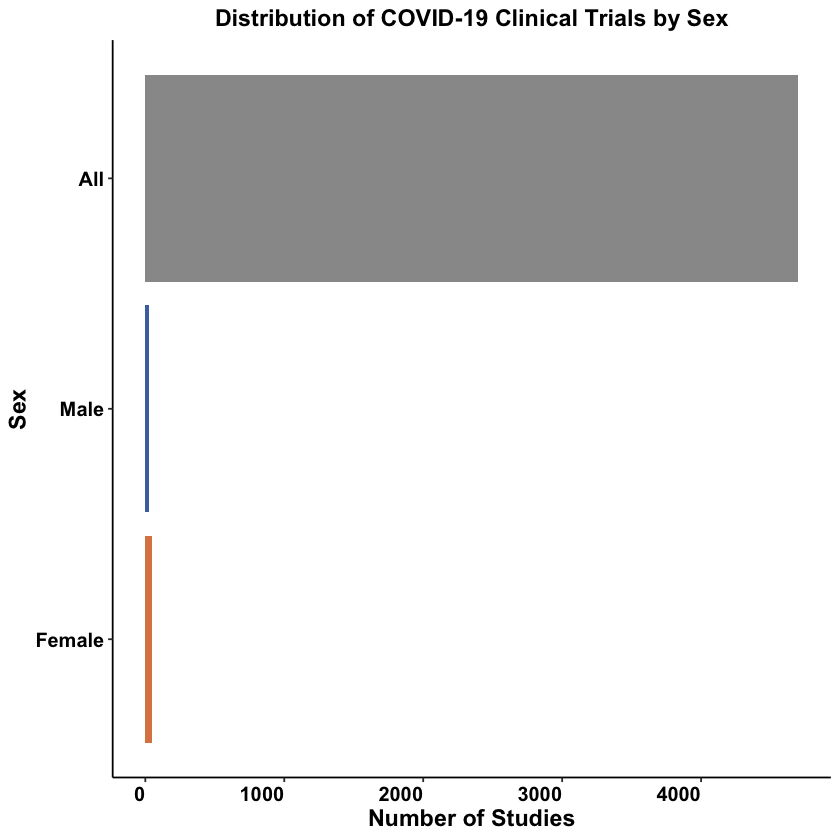

In [28]:
data  %>% 
select(phases, sex) %>% 
group_by(sex) %>%
  summarise(
    n_studies = n(),
    .groups = "drop"
  ) %>% 
  mutate(sex = factor(sex, levels = c("Female", "Male", "All"))) %>% 
  ggplot(aes(x = sex, y = n_studies, fill = sex)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(
    breaks = c("All", "Male", "Female"),  # legend order
    values = c(
      "All"    = "#999999",
      "Male"   = "#4C72B0",
      "Female" = "#DD8452"
    )
  ) +
  theme_classic()+
    labs(x = "Sex", 
    y = "Number of Studies",
    title = "Distribution of COVID-19 Clinical Trials by Sex") +
    theme(
      legend.position = "none",
      axis.title = element_text(size = 14, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 12, colour = "black"),
      axis.text.y = element_text(size = 12, face = "bold",colour = "black"),
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5,colour = "black")
    )   
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/sex_distribution.png", width = 6, height = 4)

#### Monthly covid19 clinical trail #####

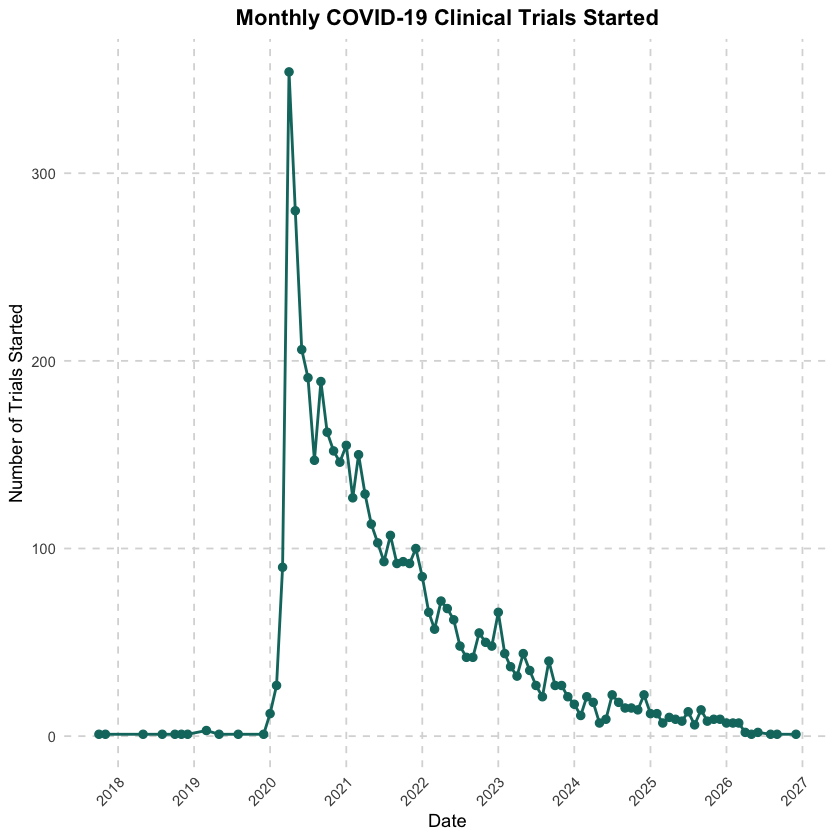

In [52]:
library(dplyr)
library(lubridate)
library(ggplot2)

data %>% 
  mutate(
    start_date = parse_date_time(start_date, orders = c("ymd", "ym", "y")),
    start_date = as.Date(start_date)) %>%
  filter(!is.na(start_date),
         start_date >= as.Date("2017-01-01"),
         start_date <= as.Date("2026-12-31")) %>%
  mutate(start_date = floor_date(start_date, "month")) %>%
  count(start_date, name = "n_studies") %>%

  ggplot(aes(x = start_date, y = n_studies)) +
  geom_line(color = "#0F766E", linewidth = 0.8) +
  geom_point(color = "#0F766E", size = 2) +
  
  scale_x_date(date_labels = "%Y", date_breaks = "1 year") +
  
  labs(
    title = "Monthly COVID-19 Clinical Trials Started",
    x = "Date",
    y = "Number of Trials Started"
  ) +
  
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(linetype = "dashed", color = "gray85"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/monthly_covid19_trials_over_time.png", width = 6, height = 4)

In [53]:
colnames(data)

[1] "nct_number"              "study_title"            
 [3] "study_url"               "study_status"           
 [5] "brief_summary"           "study_results"          
 [7] "conditions"              "interventions"          
 [9] "sponsor"                 "collaborators"          
[11] "sex"                     "age"                    
[13] "phases"                  "study_type"             
[15] "start_date"              "primary_completion_date"
[17] "completion_date"         "results_first_posted"   
[19] "locations"

##### Clinical studies vs Trial status #####

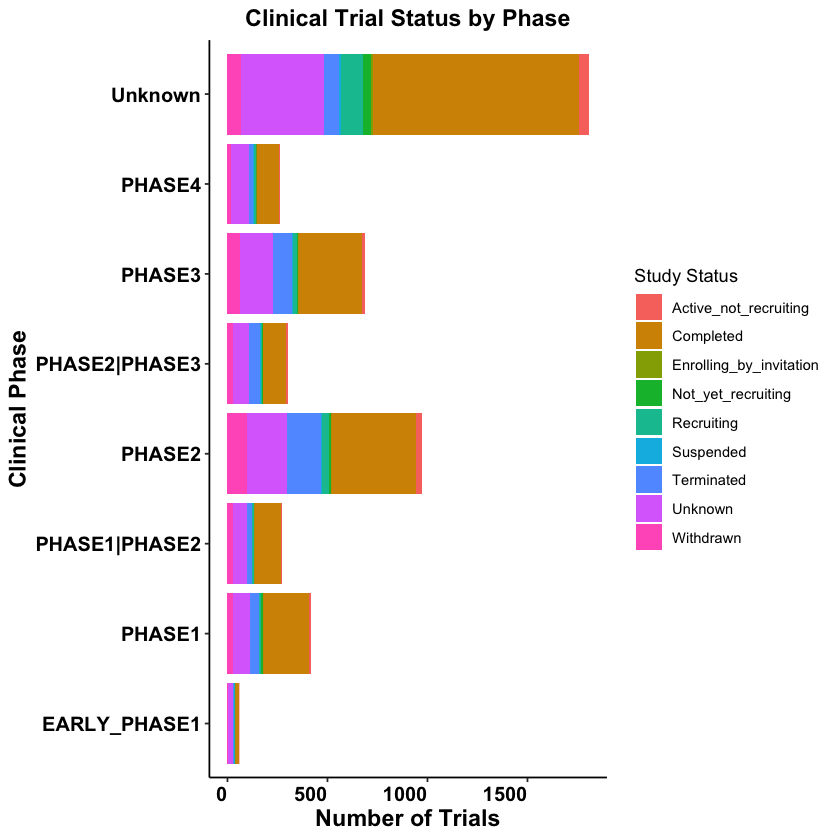

In [67]:
library(dplyr)
library(stringr)
library(tidyr)

status_phase_summary <- data %>%
  select(phases, study_status) %>%
  mutate(
    phases = str_to_upper(phases),
    study_status = str_to_title(study_status),
    
    # handle missing
    phases = tidyr::replace_na(phases, "Unknown"),
    study_status = tidyr::replace_na(study_status, "Unknown")
  )%>%
  count(phases, study_status)



  library(ggplot2)

ggplot(status_phase_summary,
       aes(x = phases, y = n, fill = study_status)) +
  geom_col(position = "stack") +
  coord_flip() +
  
  labs(
    x = "Clinical Phase",
    y = "Number of Trials",
    fill = "Study Status",
    title = "Clinical Trial Status by Phase"
  ) +
  
  theme_classic() +
  theme(
      legend.position = "right",
      axis.title = element_text(size = 14, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 12, colour = "black"),
      axis.text.y = element_text(size = 12, face = "bold",colour = "black"),
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5,colour = "black")
    ) 
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/status_by_phase.png", width = 6, height = 8)

In [91]:
library(dplyr)
library(lubridate)
library(ggplot2)

plot_data <- data %>%
  mutate(
    start_date = parse_date_time(start_date, orders = c("ymd", "ym", "y")),
    start_date = as.Date(start_date)
  ) %>%
  filter(!is.na(start_date)) %>%
  
  # keep only required years
  filter(year(start_date) %in% c(2019, 2020, 2021, 2022)) %>%
  
  mutate(
    year = year(start_date),
    month = month(start_date, label = TRUE, abbr = TRUE)  # Jan, Feb...
  ) %>%
  
  count(year, month, name = "n_studies")


  plot_data <- plot_data %>%
  mutate(
    month = factor(month, levels = month.abb)  # Jan → Dec
  )

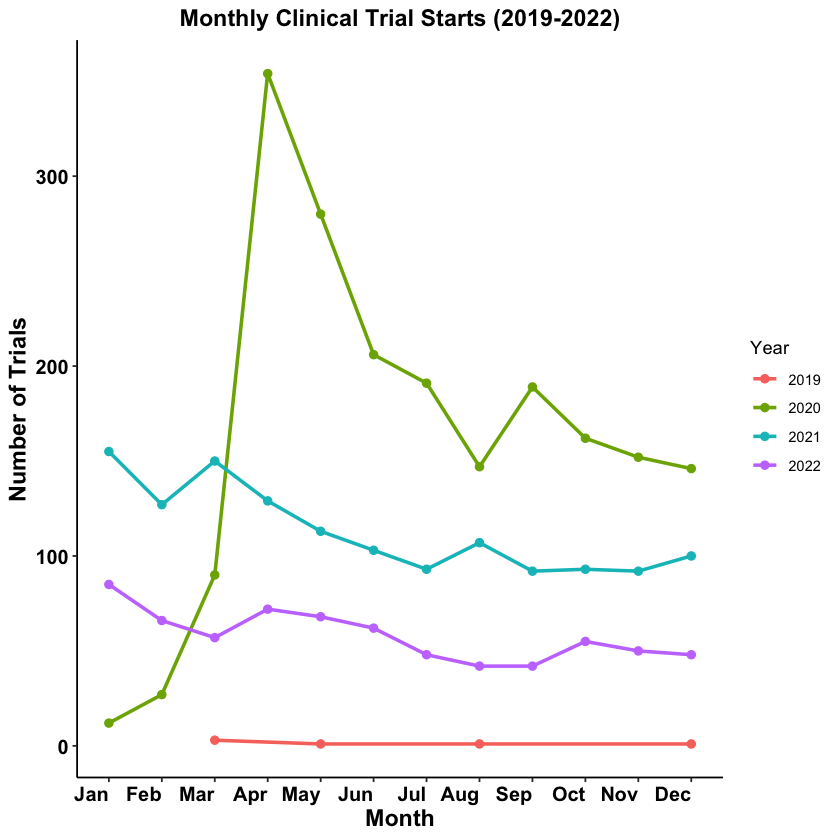

In [95]:
ggplot(plot_data,
       aes(x = month, y = n_studies, color = factor(year), group = year)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  
  labs(
    x = "Month",
    y = "Number of Trials",
    color = "Year",
    title = "Monthly Clinical Trial Starts (2019-2022)"
  ) +
  
  theme_classic() +
  theme(
      legend.position = "right",
      axis.title = element_text(size = 14, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 0, hjust = 1, face = "bold", size = 12, colour = "black"),
      axis.text.y = element_text(size = 12, face = "bold",colour = "black"),
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5,colour = "black")
    ) 
ggsave("/Volumes/NGS/Rproject/Clinical_trail_Covid19_studies/visuals/monthly_covid19_trials_over_2019_2022_time.png", width = 6, height = 4)